In [3]:
from pathlib import Path
from PIL import Image
import re
import json

# Project root is one level above notebooks/
PROJECT_ROOT = Path("..")

PAGES_DIR = PROJECT_ROOT / "data" / "extracted" / "pages"
VISUAL_DIR = PROJECT_ROOT / "data" / "extracted" / "visual_candidates"

VISUAL_DIR.mkdir(parents=True, exist_ok=True)

# Load cleaned page text
with open(
    PROJECT_ROOT / "data" / "extracted" / "chapter_01_cleaned.json",
    "r",
    encoding="utf-8"
) as f:
    pages = json.load(f)

print("Pages loaded:", len(pages))
print("Pages directory:", PAGES_DIR.resolve())
print("Visual candidate directory:", VISUAL_DIR.resolve())

Pages loaded: 44
Pages directory: C:\Users\91832\Desktop\MultiModal_RAG\data\extracted\pages
Visual candidate directory: C:\Users\91832\Desktop\MultiModal_RAG\data\extracted\visual_candidates


In [6]:
visual_patterns = [
    r"\bFig\.?\s*\d+\.\d+",
    r"\bFigure\s+\d+\.\d+",
    r"\bTable\s+\d+\.\d+",
    r"\bExample\s+\d+\.\d+",
]

candidates = []

for page in pages:
    page_num = page["page"]
    text = page["text"]

    matches = []

    for pattern in visual_patterns:
        matches.extend(re.findall(pattern, text, flags=re.IGNORECASE))

    if matches:
        candidates.append({
            "page": page_num,
            "matches": sorted(set(matches)),
            "text_preview": text[:300]
        })

print("Candidate pages:", len(candidates))

for item in candidates:
    print(
        f"Page {item['page']:02d} | "
        f"{item['matches']}"
    )

Candidate pages: 35
Page 02 | ['FIGURE 1.1', 'Fig. 1.1']
Page 03 | ['Fig. 1.2']
Page 04 | ['FIGURE 1.2']
Page 06 | ['EXAMPLE 1.1', 'EXAMPLE 1.2', 'Example 1.1', 'Example 1.2']
Page 08 | ['FIGURE 1.3', 'Fig. 1.3', 'Fig.1.3']
Page 09 | ['EXAMPLE 1.3', 'Example 1.3']
Page 10 | ['EXAMPLE 1.3', 'EXAMPLE 1.4', 'Example 1.4', 'FIGURE 1.4']
Page 11 | ['EXAMPLE 1.4', 'FIGURE 1.5', 'Fig. 1.4', 'Fig. 1.5']
Page 12 | ['EXAMPLE 1.5', 'Example 1.5', 'FIGURE 1.6', 'Fig. 1.5', 'Fig. 1.6']
Page 13 | ['EXAMPLE 1.5', 'EXAMPLE 1.6', 'Example 1.6', 'FIGURE 1.7', 'Fig. 1.7']
Page 14 | ['EXAMPLE 1.6', 'FIGURE 1.8']
Page 16 | ['FIGURE 1.9', 'Fig. 1.9']
Page 17 | ['EXAMPLE 1.7', 'Example 1.7', 'FIGURE 1.10', 'Fig. 1.10']
Page 18 | ['EXAMPLE 1.7', 'EXAMPLE 1.8', 'Example 1.8', 'FIGURE 1.11', 'Fig. 1.11']
Page 19 | ['EXAMPLE 1.8', 'FIGURE 1.12', 'Fig. 1.11', 'Figure 1.12']
Page 20 | ['FIGURE 1.13', 'Fig. 1.13', 'Figure 1.13']
Page 21 | ['FIGURE 1.14', 'Figure 1.14']
Page 22 | ['FIGURE 1.15', 'FIGURE 1.16', 'Fig.

In [2]:
from pathlib import Path

print("Notebook is running from:")
print(Path.cwd())

print("\nDoes data folder exist?")
print(Path("data").exists())

print("\nDoes extracted folder exist?")
print(Path("data/extracted").exists())

print("\nFiles/folders in current directory:")
for p in Path.cwd().iterdir():
    print(p)

Notebook is running from:
c:\Users\91832\Desktop\MultiModal_RAG\notebooks

Does data folder exist?
True

Does extracted folder exist?
True

Files/folders in current directory:
c:\Users\91832\Desktop\MultiModal_RAG\notebooks\01_text_chunking.ipynb
c:\Users\91832\Desktop\MultiModal_RAG\notebooks\02.ipynb
c:\Users\91832\Desktop\MultiModal_RAG\notebooks\data


In [5]:
print("Number of pages:", len(pages))

print("\nKeys in first page:")
print(pages[0].keys())

print("\nFirst page:")
print(pages[0])

Number of pages: 44

Keys in first page:
dict_keys(['page', 'text'])

First page:
{'page': 1, 'text': 'Chapter One\nELECTRIC CHARGES\nAND FIELDS\n1.1 INTRODUCTION\nAll of us have the experience of seeing a spark or hearing a crackle when\nwe take off our synthetic clothes or sweater, particularly in dry weather.\nHave you ever tried to find any explanation for this phenomenon? Another\ncommon example of electric discharge is the lightning that we see in the\nsky during thunderstorms. We also experience a sensation of an electric\nshock either while opening the door of a car or holding the iron bar of a\nbus after sliding from our seat. The reason for these experiences is\ndischarge of electric charges through our body, which were accumulated\ndue to rubbing of insulating surfaces. You might have also heard that\nthis is due to generation of static electricity. This is precisely the topic we\nare going to discuss in this and the next chapter. Static means anything\nthat does not move or

In [7]:
import re
from collections import defaultdict

figure_pages = defaultdict(set)

for page in pages:
    page_num = page["page"]
    text = page["text"]

    # Match Fig. 1.1, Fig 1.1, Figure 1.1, FIGURE 1.1, etc.
    matches = re.findall(
        r'\b(?:fig(?:ure)?\.?)\s*(1\.\d+)',
        text,
        flags=re.IGNORECASE
    )

    for number in matches:
        figure_pages[f"Fig. {number}"].add(page_num)

# Convert sets to sorted lists
figure_pages = {
    fig: sorted(page_list)
    for fig, page_list in figure_pages.items()
}

print(f"Unique figures found: {len(figure_pages)}\n")

for fig, page_list in figure_pages.items():
    print(f"{fig:12} → pages {page_list}")

Unique figures found: 31

Fig. 1.1     → pages [2]
Fig. 1.2     → pages [3, 4]
Fig. 1.3     → pages [8]
Fig. 1.4     → pages [10, 11]
Fig. 1.5     → pages [11, 12]
Fig. 1.6     → pages [12]
Fig. 1.7     → pages [13]
Fig. 1.8     → pages [14]
Fig. 1.9     → pages [16]
Fig. 1.10    → pages [17]
Fig. 1.11    → pages [18, 19]
Fig. 1.12    → pages [19]
Fig. 1.13    → pages [20]
Fig. 1.14    → pages [21]
Fig. 1.15    → pages [22]
Fig. 1.16    → pages [22]
Fig. 1.17    → pages [23, 24]
Fig. 1.18    → pages [25]
Fig. 1.19    → pages [27]
Fig. 1.20    → pages [27]
Fig. 1.21    → pages [28, 29]
Fig. 1.22    → pages [29]
Fig. 1.23    → pages [30]
Fig. 1.24    → pages [31]
Fig. 1.25    → pages [32]
Fig. 1.26    → pages [33]
Fig. 1.27    → pages [34]
Fig. 1.28    → pages [35]
Fig. 1.29    → pages [36]
Fig. 1.30    → pages [42, 43]
Fig. 1.31    → pages [43]


In [8]:
from pathlib import Path
from PIL import Image

PAGES_DIR = Path("../data/extracted/pages")
CROP_DIR = Path("../data/extracted/visual_candidates")

CROP_DIR.mkdir(parents=True, exist_ok=True)

figures_to_test = {
    "Fig. 1.1": [2],
    "Fig. 1.2": [3, 4],
    "Fig. 1.3": [8],
}

print("Pages directory:", PAGES_DIR.resolve())
print("Exists:", PAGES_DIR.exists())

Pages directory: C:\Users\91832\Desktop\MultiModal_RAG\data\extracted\pages
Exists: True


In [9]:
from PIL import Image, ImageDraw

for fig, page_numbers in figures_to_test.items():
    for page_num in page_numbers:
        page_path = PAGES_DIR / f"page_{page_num:02d}.png"

        if not page_path.exists():
            print("Missing:", page_path)
            continue

        img = Image.open(page_path)

        # Resize while preserving aspect ratio
        max_width = 900
        scale = max_width / img.width
        resized = img.resize(
            (max_width, int(img.height * scale))
        )

        output_name = (
            f"{fig.replace('.', '_').replace(' ', '_')}"
            f"_page_{page_num:02d}.png"
        )

        resized.save(CROP_DIR / output_name)

        print(
            f"{fig} | page {page_num} | "
            f"original={img.size} | saved={output_name}"
        )

Fig. 1.1 | page 2 | original=(1224, 1556) | saved=Fig__1_1_page_02.png
Fig. 1.2 | page 3 | original=(1224, 1556) | saved=Fig__1_2_page_03.png
Fig. 1.2 | page 4 | original=(1224, 1556) | saved=Fig__1_2_page_04.png
Fig. 1.3 | page 8 | original=(1224, 1556) | saved=Fig__1_3_page_08.png


In [14]:
import pymupdf
import re

PDF_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "class_12_physics_part01"
    / "chapter_01_electric_charges_and_fields.pdf"
)

doc = pymupdf.open(PDF_PATH)

figures_to_find = ["1.1", "1.2", "1.3"]

figure_locations = {}

for fig_num in figures_to_find:
    locations = []

    pattern = re.compile(
        rf'\b(?:Fig(?:ure)?\.?)\s*{re.escape(fig_num)}\b',
        re.IGNORECASE
    )

    for page_index, page in enumerate(doc):
        blocks = page.get_text("blocks")

        for block in blocks:
            x0, y0, x1, y1, text = block[:5]

            if pattern.search(text):
                locations.append({
                    "page": page_index + 1,
                    "bbox": (x0, y0, x1, y1),
                    "text": text.strip()
                })

    figure_locations[f"Fig. {fig_num}"] = locations


for fig, locations in figure_locations.items():
    print(f"\n{fig}")

    for loc in locations:
        print(f"  Page: {loc['page']}")
        print(f"  BBox: {loc['bbox']}")
        print(f"  Text: {loc['text'][:150]}")


Fig. 1.1
  Page: 2
  BBox: (191.99998474121094, 300.8790588378906, 552.0011596679688, 402.8820495605469)
  Text: It was observed that if two glass rods rubbed with wool or silk cloth
are brought close to each other, they repel each other [Fig. 1.1(a)]. The
two st
  Page: 2
  BBox: (203.27999877929688, 235.06198120117188, 540.719970703125, 245.6259765625)
  Text: FIGURE 1.1 Rods: like charges repel and unlike charges attract each other.

Fig. 1.2
  Page: 3
  BBox: (59.999961853027344, 100.23898315429688, 420.0015869140625, 176.5619354248047)
  Text: A simple apparatus to detect charge on a body is the gold-leaf
electroscope [Fig. 1.2(a)]. It consists of a vertical metal rod housed in a
box, with t
  Page: 4
  BBox: (86.16000366210938, 349.302001953125, 223.43995666503906, 359.8659973144531)
  Text: FIGURE 1.2 Electroscopes: (a)

Fig. 1.3
  Page: 8
  BBox: (192.00003051757812, 286.802978515625, 552.0318603515625, 392.4064636230469)
  Text: Since force is a vector, it is better to write


In [12]:
from pathlib import Path

PROJECT_ROOT = Path("..")

RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("RAW directory:")
print(RAW_DIR.resolve())
print("\nFiles found:")

for file in RAW_DIR.iterdir():
    print(file.name)

RAW directory:
C:\Users\91832\Desktop\MultiModal_RAG\data\raw

Files found:
class_12_physics_part01


In [13]:
from pathlib import Path

RAW_DIR = PROJECT_ROOT / "data" / "raw"

for path in RAW_DIR.rglob("*"):
    print(path)

..\data\raw\class_12_physics_part01
..\data\raw\class_12_physics_part01\chapter_01_electric_charges_and_fields.pdf
..\data\raw\class_12_physics_part01\chapter_02_electrostatic_potential_and_capacitance.pdf
..\data\raw\class_12_physics_part01\chapter_03_current_electricity.pdf
..\data\raw\class_12_physics_part01\chapter_04_moving_charges_and_magnetism.pdf
..\data\raw\class_12_physics_part01\chapter_05_magnetism_and_matter.pdf
..\data\raw\class_12_physics_part01\chapter_06_electromagnetic_induction.pdf
..\data\raw\class_12_physics_part01\chapter_07_alternating_current.pdf
..\data\raw\class_12_physics_part01\chapter_08_electromagnetic_waves.pdf


In [15]:
# Inspect page 2 layout around Fig. 1.1

page = doc[1]  # PDF page 2

blocks = page.get_text("blocks")

# Sort blocks top-to-bottom
blocks = sorted(blocks, key=lambda b: (b[1], b[0]))

for i, block in enumerate(blocks):
    x0, y0, x1, y1, text = block[:5]

    print(
        f"\nBLOCK {i}"
        f"\n  bbox = ({x0:.1f}, {y0:.1f}, {x1:.1f}, {y1:.1f})"
        f"\n  text = {text.strip()[:250]}"
    )


BLOCK 0
  bbox = (140.4, 68.6, 207.8, 88.6)
  text = Physics

BLOCK 1
  bbox = (203.3, 235.1, 540.7, 245.6)
  text = FIGURE 1.1 Rods: like charges repel and unlike charges attract each other.

BLOCK 2
  bbox = (192.0, 262.5, 552.0, 300.4)
  text = elektron meaning amber. Many such pairs of materials were known which
on rubbing could attract light objects like straw, pith balls and bits of
papers.

BLOCK 3
  bbox = (192.0, 300.9, 552.0, 402.9)
  text = It was observed that if two glass rods rubbed with wool or silk cloth
are brought close to each other, they repel each other [Fig. 1.1(a)]. The
two strands of wool or two pieces of silk cloth, with which the rods were
rubbed, also repel each other. H

BLOCK 4
  bbox = (192.0, 403.4, 552.0, 519.0)
  text = These seemingly simple facts  were established from years of efforts
and careful experiments and their analyses. It was concluded, after many
careful studies by different scientists, that there were only two kinds of
an entry which is c

In [16]:
from PIL import Image, ImageDraw

page_num = 2

page_path = PAGES_DIR / f"page_{page_num:02d}.png"
img = Image.open(page_path).convert("RGB")

draw = ImageDraw.Draw(img)

# PDF coordinates are based on ~612 x 792 points.
# Rendered image is 1224 x 1556, approximately 2x scale.
scale_x = img.width / doc[page_num - 1].rect.width
scale_y = img.height / doc[page_num - 1].rect.height

caption_y_pdf = 235.1
caption_y_px = int(caption_y_pdf * scale_y)

# Draw line at caption position
draw.line(
    [(0, caption_y_px), (img.width, caption_y_px)],
    fill="red",
    width=5
)

output_path = CROP_DIR / "debug_fig_1_1_page_02.png"
img.save(output_path)

print("Saved:", output_path.resolve())
print("Image size:", img.size)
print("Caption Y pixel:", caption_y_px)

Saved: C:\Users\91832\Desktop\MultiModal_RAG\data\extracted\visual_candidates\debug_fig_1_1_page_02.png
Image size: (1224, 1556)
Caption Y pixel: 470


In [ ]:
from PIL import Image

page_num = 2

page_path = PAGES_DIR / f"page_{page_num:02d}.png"
img = Image.open(page_path).convert("RGB")

# Caption coordinates from the PDF
caption_x0 = 203.28
caption_y0 = 235.06
caption_x1 = 540.72
caption_y1 = 245.63

# Convert PDF coordinates → PNG pixels
page = doc[page_num - 1]

scale_x = img.width / page.rect.width
scale_y = img.height / page.rect.height

x0 = int(caption_x0 * scale_x)
y0 = int(caption_y0 * scale_y)
x1 = int(caption_x1 * scale_x)
y1 = int(caption_y1 * scale_y)

# Candidate figure region:
# full content width, from near the top of the page
# down to just above the caption.
crop_x0 = int(150 * scale_x)
crop_x1 = int(570 * scale_x)

crop_y0 = int(100 * scale_y)
crop_y1 = int((caption_y0 - 8) * scale_y)

crop = img.crop((crop_x0, crop_y0, crop_x1, crop_y1))

output_path = CROP_DIR / "fig_1_1_candidate.png"
crop.save(output_path)

print("Saved:", output_path.resolve())
print("Crop size:", crop.size)

Saved: C:\Users\91832\Desktop\MultiModal_RAG\data\extracted\visual_candidates\fig_1_1_candidate.png
Crop size: (840, 254)


In [25]:
from PIL import Image


def create_visual_candidate(
    page_num,
    caption_bbox,
    figure_id,
    padding_x=20,
    padding_top=20,
    padding_bottom=10,
):
    """
    Create a candidate crop using the caption width
    to determine whether the figure is wide or left-column.
    """

    # ---------------------------------------------------------
    # 1. Load rendered page
    # ---------------------------------------------------------
    page_path = PAGES_DIR / f"page_{page_num:02d}.png"
    img = Image.open(page_path).convert("RGB")

    page = doc[page_num - 1]

    scale_x = img.width / page.rect.width
    scale_y = img.height / page.rect.height

    caption_x0, caption_y0, caption_x1, caption_y1 = caption_bbox

    caption_width = caption_x1 - caption_x0

    # ---------------------------------------------------------
    # 2. Determine figure layout from caption width
    # ---------------------------------------------------------
    if caption_width > 250:
        # Wide figure
        col_x0_pdf = 100
        col_x1_pdf = 580

        layout = "wide"

    else:
        # Left-column figure
        col_x0_pdf = 70
        col_x1_pdf = 285

        layout = "left-column"

    # ---------------------------------------------------------
    # 3. Convert coordinates to pixels
    # ---------------------------------------------------------
    x0 = int((col_x0_pdf - padding_x) * scale_x)
    x1 = int((col_x1_pdf + padding_x) * scale_x)

    y0 = int(70 * scale_y)
    y1 = int((caption_y0 - padding_bottom) * scale_y)

    # Keep inside image
    x0 = max(0, x0)
    y0 = max(0, y0)
    x1 = min(img.width, x1)
    y1 = min(img.height, y1)

    # ---------------------------------------------------------
    # 4. Crop
    # ---------------------------------------------------------
    candidate = img.crop((x0, y0, x1, y1))

    # ---------------------------------------------------------
    # 5. Save
    # ---------------------------------------------------------
    filename = (
        f"{figure_id.replace('.', '_').replace(' ', '_')}"
        f"_page_{page_num:02d}_candidate.png"
    )

    output_path = CROP_DIR / filename
    candidate.save(output_path)

    print(
        f"{figure_id} | page {page_num} | "
        f"layout={layout} | "
        f"crop=({x0}, {y0}, {x1}, {y1}) | "
        f"size={candidate.size}"
    )

    return output_path

In [27]:
fig_1_1 = create_visual_candidate(
    page_num=2,
    caption_bbox=(203.28, 235.06, 540.72, 245.63),
    figure_id="Fig. 1.1",
)

fig_1_2 = create_visual_candidate(
    page_num=4,
    caption_bbox=(86.16, 349.302, 223.44, 359.866),
    figure_id="Fig. 1.2",
)

fig_1_3 = create_visual_candidate(
    page_num=8,
    caption_bbox=(107.28, 335.853, 252.73, 347.476),
    figure_id="Fig. 1.3",
)

Fig. 1.1 | page 2 | layout=wide | crop=(160, 140, 1200, 450) | size=(1040, 310)
Fig. 1.2 | page 4 | layout=left-column | crop=(100, 140, 610, 678) | size=(510, 538)
Fig. 1.3 | page 8 | layout=left-column | crop=(100, 140, 610, 652) | size=(510, 512)


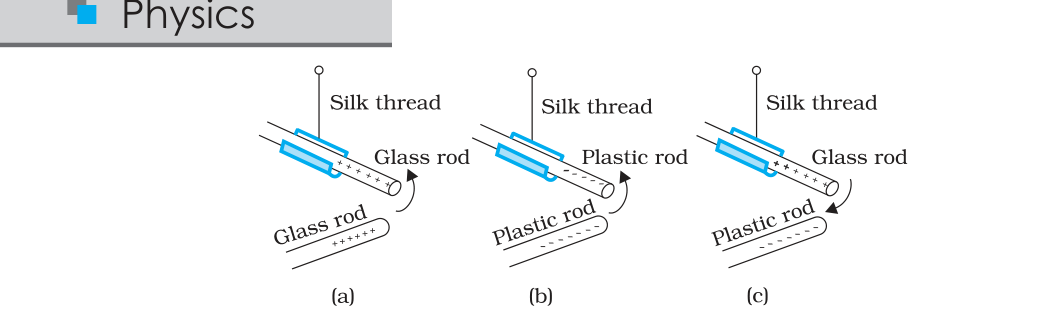

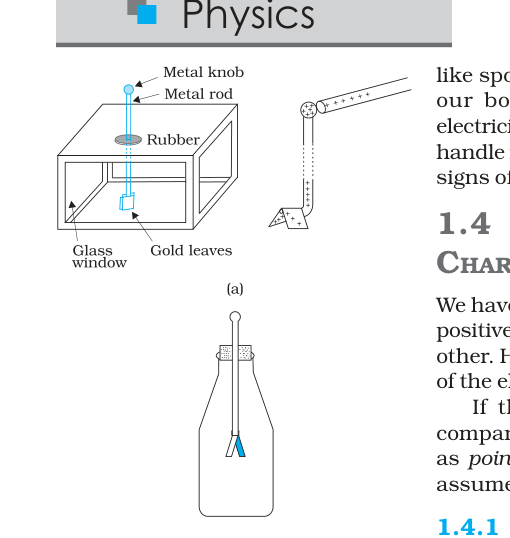

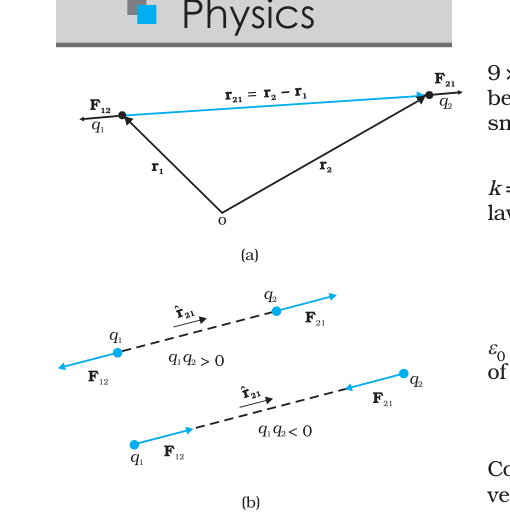

In [28]:
from IPython.display import display

display(Image.open(fig_1_1))
display(Image.open(fig_1_2))
display(Image.open(fig_1_3))

In [29]:
fig_1_1 = create_visual_candidate(
    page_num=2,
    caption_bbox=(203.28, 235.06, 540.72, 245.63),
    figure_id="Fig. 1.1",
)

fig_1_2 = create_visual_candidate(
    page_num=4,
    caption_bbox=(86.16, 349.302, 223.44, 359.866),
    figure_id="Fig. 1.2",
)

fig_1_3 = create_visual_candidate(
    page_num=8,
    caption_bbox=(107.28, 335.853, 252.73, 347.476),
    figure_id="Fig. 1.3",
)

Fig. 1.1 | page 2 | layout=wide | crop=(160, 140, 1200, 450) | size=(1040, 310)
Fig. 1.2 | page 4 | layout=left-column | crop=(100, 140, 610, 678) | size=(510, 538)
Fig. 1.3 | page 8 | layout=left-column | crop=(100, 140, 610, 652) | size=(510, 512)


In [30]:
from PIL import Image


def create_visual_candidate(
    page_num,
    caption_bbox,
    figure_id,
    padding_x=20,
    padding_bottom=10,
):
    """
    Generate a candidate visual crop from a rendered page.

    The layout is estimated from the caption width.
    """

    page_path = PAGES_DIR / f"page_{page_num:02d}.png"
    img = Image.open(page_path).convert("RGB")

    page = doc[page_num - 1]

    # PDF → PNG scale
    scale_x = img.width / page.rect.width
    scale_y = img.height / page.rect.height

    caption_x0, caption_y0, caption_x1, caption_y1 = caption_bbox

    caption_width = caption_x1 - caption_x0

    # ---------------------------------------------------------
    # Determine layout
    # ---------------------------------------------------------
    if caption_width > 250:
        layout = "wide"

        col_x0_pdf = 100
        col_x1_pdf = 580

    else:
        layout = "left-column"

        col_x0_pdf = 70
        col_x1_pdf = 285

    # ---------------------------------------------------------
    # Convert to pixels
    # ---------------------------------------------------------
    x0 = int((col_x0_pdf - padding_x) * scale_x)
    x1 = int((col_x1_pdf + padding_x) * scale_x)

    y0 = int(70 * scale_y)
    y1 = int((caption_y0 - padding_bottom) * scale_y)

    # Safety bounds
    x0 = max(0, x0)
    y0 = max(0, y0)
    x1 = min(img.width, x1)
    y1 = min(img.height, y1)

    # ---------------------------------------------------------
    # Crop
    # ---------------------------------------------------------
    candidate = img.crop((x0, y0, x1, y1))

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------
    filename = (
        f"{figure_id.replace('.', '_').replace(' ', '_')}"
        f"_page_{page_num:02d}_candidate.png"
    )

    output_path = CROP_DIR / filename
    candidate.save(output_path)

    return {
        "layout": layout,
        "crop_bbox_px": [x0, y0, x1, y1],
        "asset_path": str(output_path),
        "size": list(candidate.size),
    }

In [32]:
import re

def find_figure_captions(doc):
    """
    Find FIGURE 1.x captions and their PDF bounding boxes.
    """

    figures = {}

    for page_idx in range(len(doc)):
        page = doc[page_idx]
        page_num = page_idx + 1

        blocks = page.get_text("blocks")

        for block in blocks:
            x0, y0, x1, y1, text = block[:5]

            match = re.search(
                r'\bFIGURE\s+(1\.\d+)',
                text,
                flags=re.IGNORECASE
            )

            if match:
                figure_number = match.group(1)
                figure_id = f"Fig. {figure_number}"

                figures[figure_id] = {
                    "figure_id": figure_id,
                    "figure_number": figure_number,
                    "page": page_num,
                    "caption": text.strip(),
                    "caption_bbox": [
                        float(x0),
                        float(y0),
                        float(x1),
                        float(y1),
                    ],
                }

    return figures


figure_captions = find_figure_captions(doc)

print("Figures found:", len(figure_captions))

for figure_id, info in figure_captions.items():
    print(
        f"{figure_id:10} | "
        f"page={info['page']:2} | "
        f"{info['caption'][:80]}"
    )

Figures found: 31
Fig. 1.1   | page= 2 | FIGURE 1.1 Rods: like charges repel and unlike charges attract each other.
Fig. 1.2   | page= 4 | FIGURE 1.2 Electroscopes: (a)
Fig. 1.3   | page= 8 | FIGURE 1.3 (a) Geometry and
Fig. 1.4   | page=10 | FIGURE 1.4
Fig. 1.5   | page=11 | FIGURE 1.5 A system of
(a) three charges
(b) multiple charges.
Fig. 1.6   | page=12 | FIGURE 1.6
Fig. 1.7   | page=13 | FIGURE 1.7
Fig. 1.8   | page=14 | FIGURE 1.8 Electric
Fig. 1.9   | page=16 | FIGURE 1.9 Electric field at a point
Fig. 1.10  | page=17 | FIGURE 1.10
Fig. 1.11  | page=18 | FIGURE 1.11
Fig. 1.12  | page=19 | FIGURE 1.12 Field of a point charge.
Fig. 1.13  | page=20 | FIGURE 1.13  Dependence of
Fig. 1.14  | page=21 | FIGURE 1.14 Field lines due to
some simple charge configurations.
Fig. 1.15  | page=22 | FIGURE 1.15 Dependence of flux on the
Fig. 1.16  | page=22 | FIGURE 1.16
Convention for
defining normal
Fig. 1.17  | page=24 | FIGURE 1.17 Electric field of a dipole
Fig. 1.18  | page=25 | FIGURE 1

In [33]:
visual_inventory = []

for figure_id, info in figure_captions.items():

    crop_info = create_visual_candidate(
        page_num=info["page"],
        caption_bbox=info["caption_bbox"],
        figure_id=figure_id,
    )

    record = {
        "asset_id": f"chapter01_{info['figure_number'].replace('.', '_')}",
        "figure_id": figure_id,
        "figure_number": info["figure_number"],
        "type": "figure",
        "page": info["page"],
        "caption": info["caption"],
        "caption_bbox_pdf": info["caption_bbox"],
        "layout": crop_info["layout"],
        "crop_bbox_px": crop_info["crop_bbox_px"],
        "asset_path": crop_info["asset_path"],
        "size": crop_info["size"],
        "status": "candidate",
    }

    visual_inventory.append(record)


print("Candidate assets created:", len(visual_inventory))

Candidate assets created: 31


In [34]:
inventory_path = (
    PROJECT_ROOT
    / "data"
    / "extracted"
    / "visual_candidates"
    / "chapter_01_visual_inventory.json"
)

with open(inventory_path, "w", encoding="utf-8") as f:
    json.dump(visual_inventory, f, indent=2, ensure_ascii=False)

print("Saved:", inventory_path.resolve())

Saved: C:\Users\91832\Desktop\MultiModal_RAG\data\extracted\visual_candidates\chapter_01_visual_inventory.json


In [35]:
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
import math


# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------
thumb_width = 250
thumb_height = 220
label_height = 35

columns = 4
rows = math.ceil(len(visual_inventory) / columns)

sheet_width = columns * thumb_width
sheet_height = rows * (thumb_height + label_height)


# ---------------------------------------------------------
# Create contact sheet
# ---------------------------------------------------------
contact_sheet = Image.new(
    "RGB",
    (sheet_width, sheet_height),
    "white"
)

draw = ImageDraw.Draw(contact_sheet)


for i, item in enumerate(visual_inventory):

    image_path = Path(item["asset_path"])

    img = Image.open(image_path).convert("RGB")

    # Keep aspect ratio
    img.thumbnail(
        (thumb_width - 10, thumb_height - 10)
    )

    x = (i % columns) * thumb_width
    y = (i // columns) * (thumb_height + label_height)

    # Center thumbnail
    paste_x = x + (thumb_width - img.width) // 2
    paste_y = y + (thumb_height - img.height) // 2

    contact_sheet.paste(
        img,
        (paste_x, paste_y)
    )

    # Label
    label = (
        f"{item['figure_id']} | "
        f"p.{item['page']} | "
        f"{item['layout']}"
    )

    draw.text(
        (x + 5, y + thumb_height),
        label,
        fill="black"
    )


# ---------------------------------------------------------
# Save
# ---------------------------------------------------------
contact_sheet_path = (
    PROJECT_ROOT
    / "data"
    / "extracted"
    / "visual_candidates"
    / "chapter_01_visual_contact_sheet.png"
)

contact_sheet.save(contact_sheet_path)

print("Saved:", contact_sheet_path.resolve())
print("Contact sheet size:", contact_sheet.size)

Saved: C:\Users\91832\Desktop\MultiModal_RAG\data\extracted\visual_candidates\chapter_01_visual_contact_sheet.png
Contact sheet size: (1000, 2040)


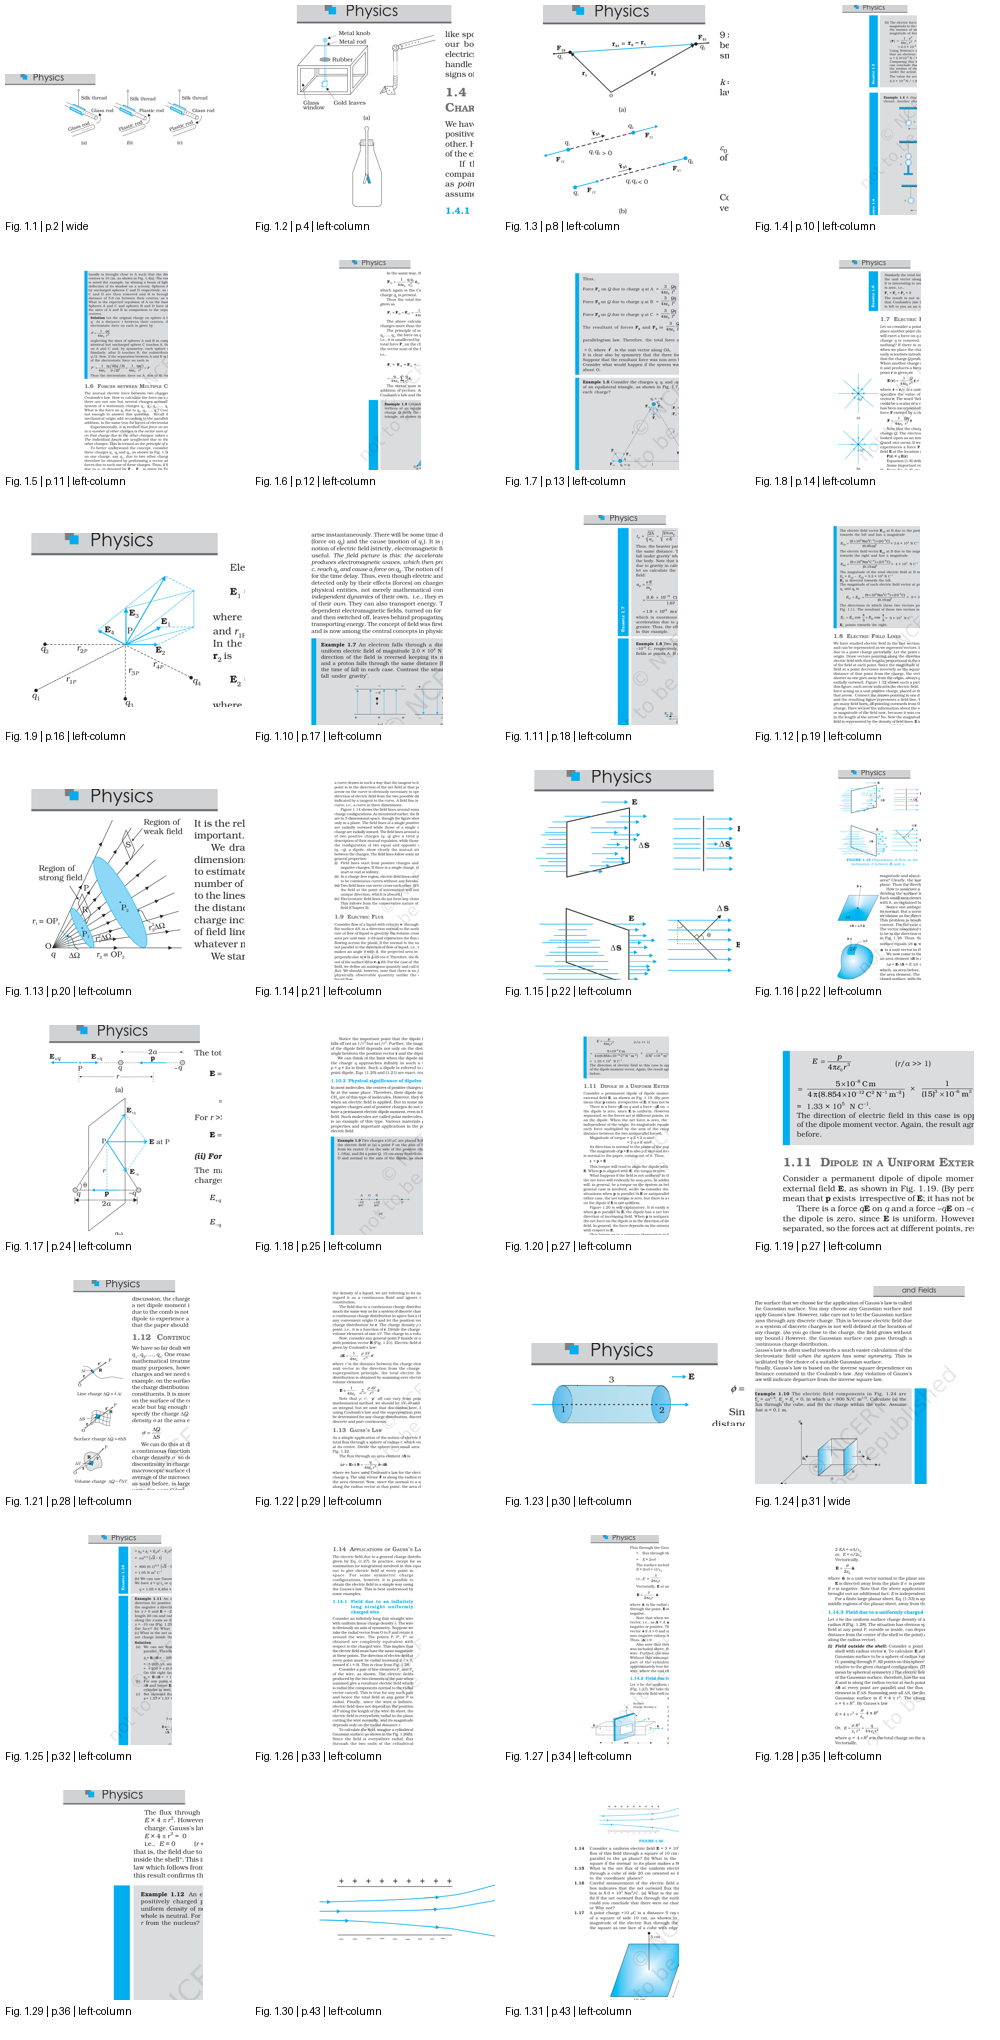

In [36]:
from IPython.display import display

display(contact_sheet)

In [37]:
page_num = 10

page = doc[page_num - 1]

drawings = page.get_drawings()

print("Page:", page_num)
print("Number of drawing objects:", len(drawings))

for i, drawing in enumerate(drawings[:50]):
    rect = drawing["rect"]

    print(
        f"{i:3d} | "
        f"x0={rect.x0:7.1f} | "
        f"y0={rect.y0:7.1f} | "
        f"x1={rect.x1:7.1f} | "
        f"y1={rect.y1:7.1f} | "
        f"w={rect.width:7.1f} | "
        f"h={rect.height:7.1f}"
    )

Page: 10
Number of drawing objects: 8132
  0 | x0=   18.7 | y0=  -20.9 | x1=   18.7 | y1=   -8.6 | w=    0.0 | h=   12.2
  1 | x0=    0.0 | y0=   -4.3 | x1=   14.6 | y1=   -4.3 | w=   14.6 | h=    0.0
  2 | x0=   18.7 | y0=  784.3 | x1=   18.7 | y1=  796.6 | w=    0.0 | h=   12.2
  3 | x0=    0.0 | y0=  780.5 | x1=   14.6 | y1=  780.5 | w=   14.6 | h=    0.0
  4 | x0=   78.0 | y0=  713.9 | x1=  114.0 | y1=  731.2 | w=   36.0 | h=   17.3
  5 | x0=    6.6 | y0=  -13.0 | x1=  612.0 | y1=   48.2 | w=  605.5 | h=   61.2
  6 | x0=   95.0 | y0=   35.9 | x1=  612.0 | y1=   39.6 | w=  517.0 | h=    3.7
  7 | x0=    6.6 | y0=   44.9 | x1=  612.1 | y1=   48.6 | w=  605.6 | h=    3.7
  8 | x0=   78.0 | y0=  -13.0 | x1=  276.0 | y1=   93.4 | w=  198.0 | h=  106.4
  9 | x0=   78.0 | y0=   91.4 | x1=  276.0 | y1=   93.6 | w=  198.0 | h=    2.2
 10 | x0=  611.8 | y0=   35.9 | x1= 1129.0 | y1=   39.6 | w=  517.2 | h=    3.7
 11 | x0=  113.7 | y0=   68.0 | x1=  123.2 | y1=   77.5 | w=    9.5 | h=    9.5

In [38]:
page_num = 10
page = doc[page_num - 1]

blocks = page.get_text("blocks")

print(f"Page {page_num} text blocks:\n")

for i, block in enumerate(blocks):
    x0, y0, x1, y1, text = block[:5]

    print(
        f"{i:3d} | "
        f"bbox=({x0:.1f}, {y0:.1f}, {x1:.1f}, {y1:.1f}) | "
        f"{text.strip()[:120]!r}"
    )

Page 10 text blocks:

  0 | bbox=(88.8, 716.1, 103.2, 728.9) | '10'
  1 | bbox=(140.4, 68.6, 207.8, 88.6) | 'Physics'
  2 | bbox=(204.0, 118.0, 534.0, 129.1) | '(b) The electric force F exerted by a proton on an electron is same in'
  3 | bbox=(222.0, 128.5, 534.0, 161.4) | 'magnitude to the force exerted by an electron on a proton; however,\nthe masses of an electron and a proton are different'
  4 | bbox=(222.0, 174.1, 252.8, 185.3) | '|F| ='
  5 | bbox=(255.8, 165.7, 277.0, 191.8) | '1\n4\n0'
  6 | bbox=(286.3, 164.7, 290.0, 171.6) | '2'
  7 | bbox=(262.1, 178.3, 289.2, 190.7) | '2\nπε'
  8 | bbox=(280.3, 167.2, 534.0, 190.4) | 'e\nr\n = 8.987 × 109 Nm2/C2 × (1.6 ×10–19C)2 / (10–10m)2'
  9 | bbox=(222.0, 190.6, 534.0, 236.9) | '= 2.3 × 10–8 N\nUsing Newton’s second law of motion, F = ma, the acceleration\nthat an electron will undergo is\na = 2.3×10'
 10 | bbox=(222.0, 236.5, 534.0, 306.9) | 'Comparing this with the value of acceleration due to gravity, we\ncan conclude that the eff

In [39]:
page_num = 11
page = doc[page_num - 1]

blocks = page.get_text("blocks")

print(f"Page {page_num} text blocks:\n")

for i, block in enumerate(blocks):
    x0, y0, x1, y1, text = block[:5]

    print(
        f"{i:3d} | "
        f"bbox=({x0:.1f}, {y0:.1f}, {x1:.1f}, {y1:.1f}) | "
        f"{text.strip()[:120]!r}"
    )

Page 11 text blocks:

  0 | bbox=(375.8, 54.3, 495.1, 69.3) | 'Electric Charges'
  1 | bbox=(398.4, 72.5, 472.6, 87.5) | 'and Fields'
  2 | bbox=(508.8, 716.1, 523.2, 728.9) | '11'
  3 | bbox=(432.6, 349.2, 443.1, 414.3) | 'EXAMPLE 1.4'
  4 | bbox=(72.0, 106.9, 402.0, 233.9) | 'handle is brought close to A such that the distance between their\ncentres is 10 cm, as shown in Fig. 1.4(a). The resulti'
  5 | bbox=(78.0, 234.6, 408.0, 268.7) | 'Solution Let the original charge on sphere A be q and that on B be\nq¢. At a distance r between their centres, the magnit'
  6 | bbox=(79.7, 275.3, 132.2, 290.7) | 'F\nqq'
  7 | bbox=(89.8, 273.0, 135.5, 299.5) | 'r\n=\n′\n1\n4\n0\n2\nπε'
  8 | bbox=(78.0, 302.3, 408.0, 371.4) | 'neglecting the sizes of spheres A and B in comparison to r. When an\nidentical but uncharged sphere C touches A, the char'
  9 | bbox=(79.7, 375.5, 241.3, 400.6) | '′ =\n′\n=\n′ =\nF\nq\nq\nr'
 10 | bbox=(215.8, 377.7, 226.3, 387.2) | 'qq'
 11 | bbox=(101.8, 376.3, 250.4, 40

In [40]:
import fitz
from PIL import Image, ImageDraw


page_num = 10

page = doc[page_num - 1]

page_path = PAGES_DIR / f"page_{page_num:02d}.png"
img = Image.open(page_path).convert("RGB")

draw = ImageDraw.Draw(img)

scale_x = img.width / page.rect.width
scale_y = img.height / page.rect.height

blocks = page.get_text("blocks")

for i, block in enumerate(blocks):
    x0, y0, x1, y1, text = block[:5]

    # PDF coordinates → PNG coordinates
    px0 = int(x0 * scale_x)
    py0 = int(y0 * scale_y)
    px1 = int(x1 * scale_x)
    py1 = int(y1 * scale_y)

    draw.rectangle(
        (px0, py0, px1, py1),
        outline="red",
        width=2
    )

    draw.text(
        (px0, max(0, py0 - 15)),
        str(i),
        fill="red"
    )


debug_path = (
    PROJECT_ROOT
    / "data"
    / "extracted"
    / "visual_candidates"
    / "page_10_text_blocks_debug.png"
)

img.save(debug_path)

print("Saved:", debug_path.resolve())

Saved: C:\Users\91832\Desktop\MultiModal_RAG\data\extracted\visual_candidates\page_10_text_blocks_debug.png


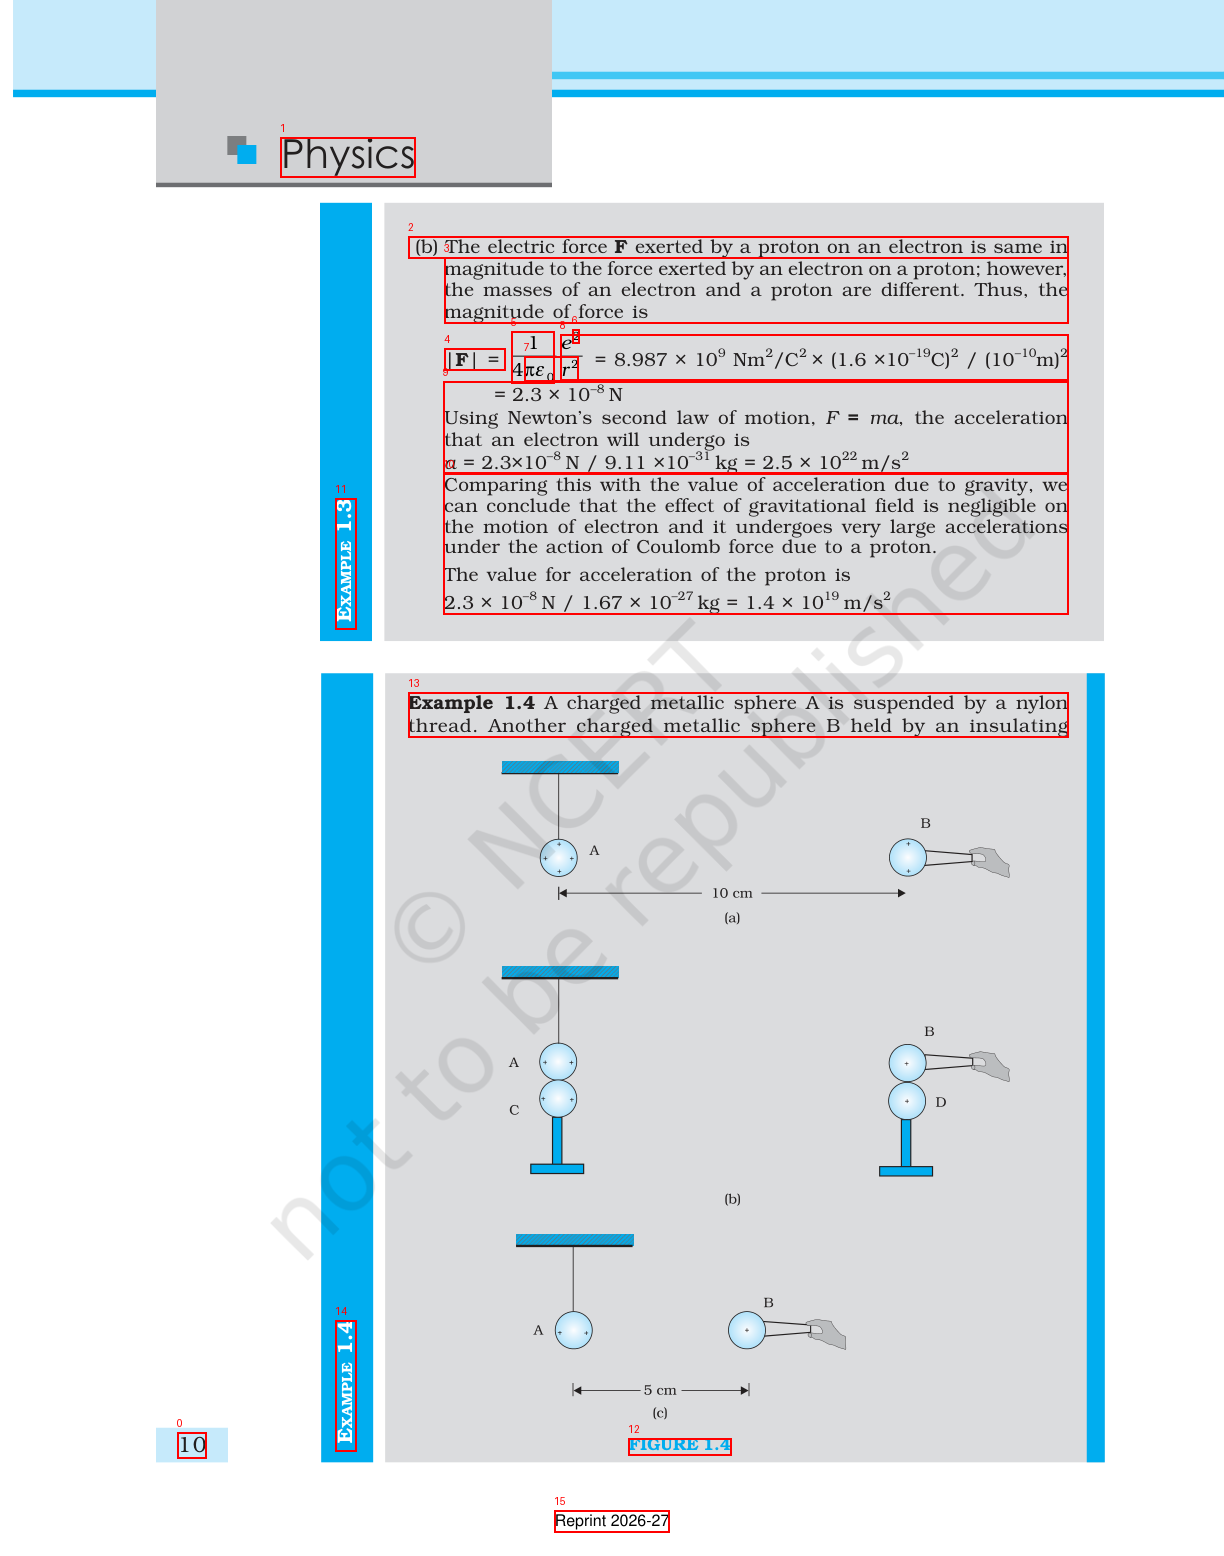

In [42]:
from IPython.display import display

display(img)

In [1]:
from pathlib import Path
from docling.document_converter import DocumentConverter

PROJECT_ROOT = Path("..")

PDF_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "class_12_physics_part01"
    / "chapter_01_electric_charges_and_fields.pdf"
)

print("PDF exists:", PDF_PATH.exists())
print("PDF path:", PDF_PATH)

converter = DocumentConverter()

docling_result = converter.convert(str(PDF_PATH))

dl_doc = docling_result.document

print("\nConversion successful!")
print("Document type:", type(dl_doc))

c:\Users\91832\Desktop\MultiModal_RAG\multimodal_rag\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PDF exists: True
PDF path: ..\data\raw\class_12_physics_part01\chapter_01_electric_charges_and_fields.pdf


[INFO] 2026-09-16 00:14:41,776 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-09-16 00:14:41,804 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-09-16 00:14:41,813 [RapidOCR] download_file.py:68: Initiating download: https://www.modelscope.cn/models/RapidAI/RapidOCR/resolve/v3.9.2/torch/PP-OCRv6/det/PP-OCRv6_det_small.pth
[INFO] 2026-09-16 00:14:45,693 [RapidOCR] download_file.py:82: Download size: 9.77MB
[INFO] 2026-09-16 00:14:48,533 [RapidOCR] download_file.py:95: Successfully saved to: C:\Users\91832\Desktop\MultiModal_RAG\multimodal_rag\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-09-16 00:14:48,533 [RapidOCR] main.py:50: Using C:\Users\91832\Desktop\MultiModal_RAG\multimodal_rag\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.pth
[INFO] 2026-09-16 00:14:48,949 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-09-16 00:14:48,949 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-09-16 00:14:48,965 [RapidOCR


Conversion successful!
Document type: <class 'docling_core.types.doc.document.DoclingDocument'>


In [2]:
# Basic Docling document inspection

print("Pages:", dl_doc.num_pages())

print("\nAvailable document attributes:")
attrs = [a for a in dir(dl_doc) if not a.startswith("_")]
print(attrs)

Pages: 44

Available document attributes:
['add_code', 'add_comment', 'add_document', 'add_field_heading', 'add_field_hint', 'add_field_item', 'add_field_key', 'add_field_region', 'add_field_value', 'add_form', 'add_formula', 'add_group', 'add_heading', 'add_inline_group', 'add_key_values', 'add_list_group', 'add_list_item', 'add_marker', 'add_node_items', 'add_ordered_list', 'add_page', 'add_picture', 'add_table', 'add_table_cell', 'add_text', 'add_title', 'add_unordered_list', 'append_child_item', 'body', 'check_version_is_compatible', 'concatenate', 'construct', 'copy', 'delete_items', 'delete_items_range', 'dict', 'export_to_dict', 'export_to_doclang', 'export_to_doctags', 'export_to_document_tokens', 'export_to_element_tree', 'export_to_html', 'export_to_markdown', 'export_to_text', 'export_to_vtt', 'extract_items_range', 'field_items', 'field_regions', 'filter', 'form_items', 'from_orm', 'furniture', 'get_visualization', 'groups', 'insert_code', 'insert_document', 'insert_form', 

In [3]:
print("Pictures detected:", len(dl_doc.pictures))
print("Tables detected:", len(dl_doc.tables))
print("Text items detected:", len(dl_doc.texts))
print("Pages in document:", len(dl_doc.pages))

Pictures detected: 99
Tables detected: 0
Text items detected: 1498
Pages in document: 44


In [4]:
print("\n--- FIRST PICTURES ---")

for i, picture in enumerate(dl_doc.pictures[:5]):
    print(f"\nPicture {i + 1}")
    print(picture)

print("\n--- FIRST TABLES ---")

for i, table in enumerate(dl_doc.tables[:5]):
    print(f"\nTable {i + 1}")
    print(table)


--- FIRST PICTURES ---

Picture 1
self_ref='#/pictures/0' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.PICTURE: 'picture'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=448.1092834472656, t=730.739198581725, r=534.3047485351562, b=643.7643045067481, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))] source=[] comments=[] captions=[] references=[] footnotes=[] image=None annotations=[]

Picture 2
self_ref='#/pictures/1' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.PICTURE: 'picture'> prov=[ProvenanceItem(page_no=2, bbox=BoundingBox(l=112.497314453125, t=710.5944517003234, r=128.47647094726562, b=695.2410519322883, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))] source=[] comments=[] captions=[] references=[] footnotes=[] image=None annotations=[]

Picture 3
self_ref='#/pictures/2' parent=RefItem(cref=

In [5]:
print(f"Total pictures detected: {len(dl_doc.pictures)}\n")

for i, picture in enumerate(dl_doc.pictures):
    prov = picture.prov[0]

    bbox = prov.bbox

    width = bbox.r - bbox.l
    height = bbox.t - bbox.b

    caption_count = len(picture.captions)
    child_count = len(picture.children)

    print(
        f"{i:03d} | "
        f"page={prov.page_no:02d} | "
        f"size={width:.1f} x {height:.1f} | "
        f"children={child_count:02d} | "
        f"captions={caption_count}"
    )

Total pictures detected: 99

000 | page=01 | size=86.2 x 87.0 | children=00 | captions=0
001 | page=02 | size=16.0 x 15.4 | children=00 | captions=0
002 | page=02 | size=326.6 x 122.8 | children=15 | captions=1
003 | page=02 | size=56.5 x 72.1 | children=00 | captions=0
004 | page=03 | size=41.8 x 36.3 | children=00 | captions=0
005 | page=04 | size=15.9 x 15.5 | children=00 | captions=0
006 | page=04 | size=179.8 x 243.8 | children=09 | captions=1
007 | page=05 | size=37.5 x 36.2 | children=00 | captions=0
008 | page=06 | size=15.9 x 15.1 | children=00 | captions=0
009 | page=06 | size=37.6 x 38.5 | children=00 | captions=0
010 | page=06 | size=60.5 x 99.7 | children=01 | captions=0
011 | page=07 | size=94.5 x 132.7 | children=00 | captions=0
012 | page=08 | size=203.4 x 219.9 | children=26 | captions=1
013 | page=09 | size=36.6 x 37.0 | children=00 | captions=0
014 | page=09 | size=65.5 x 54.0 | children=00 | captions=0
015 | page=09 | size=93.8 x 105.8 | children=00 | captions=0
016

In [6]:
# Inspect the image representation of detected pictures

for i, picture in enumerate(dl_doc.pictures):
    if picture.image is not None:
        print(f"Picture {i}: image available")
        print("Image type:", type(picture.image))
        print("Image object:", picture.image)
        break
else:
    print("No picture has an embedded image representation.")

No picture has an embedded image representation.


In [7]:
print("Potential visual regions:\n")

for i, picture in enumerate(dl_doc.pictures):
    prov = picture.prov[0]
    bbox = prov.bbox

    width = bbox.r - bbox.l
    height = bbox.t - bbox.b

    # Show reasonably substantial regions
    if width >= 100 and height >= 80:
        print(
            f"Picture {i:03d} | "
            f"page={prov.page_no:02d} | "
            f"bbox=({bbox.l:.1f}, {bbox.b:.1f}, "
            f"{bbox.r:.1f}, {bbox.t:.1f}) | "
            f"size={width:.1f} x {height:.1f} | "
            f"children={len(picture.children)} | "
            f"captions={len(picture.captions)}"
        )

Potential visual regions:

Picture 002 | page=02 | bbox=(207.7, 553.6, 534.3, 676.4) | size=326.6 x 122.8 | children=15 | captions=1
Picture 006 | page=04 | bbox=(77.1, 431.8, 256.9, 675.6) | size=179.8 x 243.8 | children=9 | captions=1
Picture 012 | page=08 | bbox=(77.8, 452.2, 281.1, 672.0) | size=203.4 x 219.9 | children=26 | captions=1
Picture 017 | page=10 | bbox=(134.1, 45.7, 552.3, 678.4) | size=418.2 x 632.7 | children=21 | captions=0
Picture 018 | page=11 | bbox=(380.7, 197.5, 534.8, 330.0) | size=154.0 x 132.5 | children=16 | captions=0
Picture 019 | page=11 | bbox=(394.1, 83.9, 507.0, 174.5) | size=112.9 x 90.5 | children=16 | captions=0
Picture 021 | page=12 | bbox=(209.2, 360.9, 551.9, 456.5) | size=342.6 x 95.6 | children=79 | captions=0
Picture 022 | page=12 | bbox=(283.4, 107.3, 459.0, 264.7) | size=175.6 x 157.4 | children=15 | captions=1
Picture 023 | page=13 | bbox=(133.7, 193.2, 417.7, 425.4) | size=284.0 x 232.1 | children=19 | captions=0
Picture 025 | page=14 | bb

In [8]:
from docling_core.types.doc import PictureItem

print("Captioned picture regions:\n")

for i, picture in enumerate(dl_doc.pictures):
    if not picture.captions:
        continue

    prov = picture.prov[0]
    bbox = prov.bbox

    width = bbox.r - bbox.l
    height = bbox.t - bbox.b

    # Extract caption text
    caption_text = []
    
    for caption_ref in picture.captions:
        ref = caption_ref.cref
        # Extract ID, e.g. "#/texts/7" -> 7
        text_id = int(ref.split("/")[-1])
        text_item = dl_doc.texts[text_id]
        caption_text.append(text_item.text)

    print(
        f"Picture {i:03d} | "
        f"page={prov.page_no:02d} | "
        f"size={width:.0f}x{height:.0f}"
    )
    print("  Caption:", " ".join(caption_text))
    print()

Captioned picture regions:

Picture 002 | page=02 | size=327x123
  Caption: FIGURE 1.1 Rods: like charges repel and unlike charges attract each other.

Picture 006 | page=04 | size=180x244
  Caption: FIGURE 1.2 Electroscopes: (a) The gold leaf electroscope, (b) Schematics of a simple electroscope.

Picture 012 | page=08 | size=203x220
  Caption: FIGURE 1.3 (a) Geometry and (b) Forces between charges.

Picture 022 | page=12 | size=176x157
  Caption: FIGURE 1.6

Picture 026 | page=14 | size=115x129
  Caption: FIGURE 1.8 Electric field (a) due to a charge Q , (b) due to a charge -Q .

Picture 028 | page=16 | size=181x141
  Caption: FIGURE 1.9 Electric field at a point due to a system of charges is the vector sum of the electric fields at the  point  due  to  individual  charges.

Picture 036 | page=18 | size=274x158
  Caption: FIGURE 1.11

Picture 038 | page=19 | size=180x179
  Caption: FIGURE 1.12 Field of a point charge.

Picture 041 | page=20 | size=160x150
  Caption: FIGURE 1.13 Depen

In [11]:
from PIL import Image

# Test with Fig. 1.1 → Picture 002
picture = dl_doc.pictures[2]

prov = picture.prov[0]
page_no = prov.page_no
bbox = prov.bbox

# Correct filename: page_02.png
page_path = PAGES_DIR / f"page_{page_no:02d}.png"
page_img = Image.open(page_path)

print("Page:", page_no)
print("Page image:", page_path)
print("Page image size:", page_img.size)
print("Docling bbox:", bbox)

Page: 2
Page image: ..\data\extracted\pages\page_02.png
Page image size: (1224, 1556)
Docling bbox: l=207.6554412841797 t=676.4290278496044 r=534.2732543945312 b=553.628724744939 coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>


In [10]:
from pathlib import Path

print("PAGES_DIR:", PAGES_DIR)
print("\nFiles found:")

for p in sorted(PAGES_DIR.iterdir())[:10]:
    print(p.name)

PAGES_DIR: ..\data\extracted\pages

Files found:
page_01.png
page_02.png
page_03.png
page_04.png
page_05.png
page_06.png
page_07.png
page_08.png
page_09.png
page_10.png


Crop coordinates: (427, 305, 1099, 532)
Crop size: (672, 227)


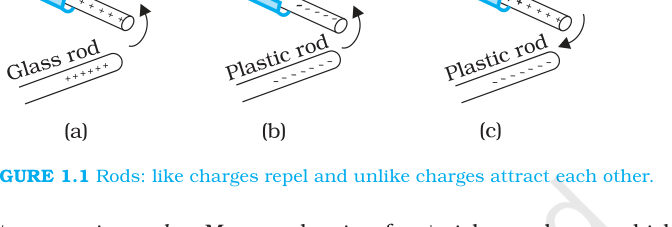

In [12]:
# Convert Docling's bottom-left PDF coordinates
# to PIL's top-left image coordinates.

pdf_width = 595.0
pdf_height = 842.0

img_width, img_height = page_img.size

scale_x = img_width / pdf_width
scale_y = img_height / pdf_height

left = int(bbox.l * scale_x)
right = int(bbox.r * scale_x)

top = int((pdf_height - bbox.t) * scale_y)
bottom = int((pdf_height - bbox.b) * scale_y)

crop = page_img.crop((left, top, right, bottom))

print("Crop coordinates:", (left, top, right, bottom))
print("Crop size:", crop.size)

display(crop)